# Big Numbers Benchmark: int vs mpz vs xmpz

In this notebook, we will test the performance of Python's native `int` against the `gmpy2` library's `mpz` (immutable) and `xmpz` (mutable) types.

We will use:
- `time.perf_counter()` for timing.
- `polars` to organize our results.
- `seaborn` and `matplotlib` to create the charts.

In [1]:
import sys
import time
import gmpy2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style for the charts
sns.set_theme(
    style='whitegrid'
)
sys.set_int_max_str_digits(500000)

print('Setup complete. Libraries loaded successfully!')

Setup complete. Libraries loaded successfully!


## Test 1: The Crossover Point (Single Operations)

Python's native `int` is very fast for small numbers. `gmpy2` is written in C, but communicating with C takes a tiny amount of time (called 'overhead').

In this test, we will multiply two numbers of increasing sizes (from 10 digits up to 100,000 digits) to see exactly when `gmpy2.mpz` becomes faster than Python's native `int`.

*Note: We don't test `xmpz` here because we are only doing a single operation, not an accumulation loop.*

In [2]:
sizes = [10, 100, 1000, 10000, 100000, 500000]
results_test1 = []

print('Running Test 1 (Multiplication)...')

for size in sizes:
    # Create two huge numbers by repeating a string
    str_a = '9' * size
    str_b = '8' * size

    # 1. Test Python native int
    num1_int = int(str_a)
    num2_int = int(str_b)

    start = time.perf_counter()
    _ = num1_int * num2_int
    end = time.perf_counter()
    results_test1.append({'Digits': size, 'Type': 'Python int', 'Time_Seconds': end - start})

    # 2. Test gmpy2 mpz
    num1_mpz = gmpy2.mpz(str_a)
    num2_mpz = gmpy2.mpz(str_b)

    start = time.perf_counter()
    _ = num1_mpz * num2_mpz
    end = time.perf_counter()
    results_test1.append({'Digits': size, 'Type': 'gmpy2 mpz', 'Time_Seconds': end - start})

print('Test 1 finished!')

Running Test 1 (Multiplication)...
Test 1 finished!


## Test 2: Memory Stress Test (Accumulation)

Every time you do `a += 1` with a normal `int` or `mpz`, Python destroys the old number in memory and creates a new one. This takes time.
The `xmpz` type is **mutable**, meaning it updates the number directly in the same memory space. Let's see how much time this saves in a loop of 5 million additions.

In [3]:
iterations = 5_000_000
results_test2 = []

print(f'Running Test 2 ({iterations} additions)...')

# 1. Python int
val_int = 0
start = time.perf_counter()
for i in range(iterations):
    val_int += 1
end = time.perf_counter()
results_test2.append({'Type': 'Python int', 'Time_Seconds': end - start})

# 2. gmpy2 mpz
val_mpz = gmpy2.mpz(0)
start = time.perf_counter()
for i in range(iterations):
    val_mpz += 1
end = time.perf_counter()
results_test2.append({'Type': 'gmpy2 mpz', 'Time_Seconds': end - start})

# 3. gmpy2 xmpz (Mutable)
val_xmpz = gmpy2.xmpz(0)
start = time.perf_counter()
for i in range(iterations):
    val_xmpz += 1
end = time.perf_counter()
results_test2.append({'Type': 'gmpy2 xmpz', 'Time_Seconds': end - start})

print('Test 2 finished!')

Running Test 2 (5000000 additions)...
Test 2 finished!


## Test 3: Iterative Factorial

Let's test a real-world mathematical scenario: calculating a large factorial manually using a loop (e.g., `100,000!`).
This will combine the massive size advantage of GMP's multiplication algorithms with the memory-saving advantage of `xmpz`.

In [4]:
target_factorial = 100_000
results_test3 = []

print(f'Running Test 3 (Calculating {target_factorial}! manually)...')

# 1. Python int
fact_int = 1
start = time.perf_counter()
for i in range(1, target_factorial + 1):
    fact_int *= i
end = time.perf_counter()
results_test3.append({'Type': 'Python int', 'Time_Seconds': end - start})

# 2. gmpy2 mpz
fact_mpz = gmpy2.mpz(1)
start = time.perf_counter()
for i in range(1, target_factorial + 1):
    fact_mpz *= i
end = time.perf_counter()
results_test3.append({'Type': 'gmpy2 mpz', 'Time_Seconds': end - start})

# 3. gmpy2 xmpz
fact_xmpz = gmpy2.xmpz(1)
start = time.perf_counter()
for i in range(1, target_factorial + 1):
    fact_xmpz *= i
end = time.perf_counter()
results_test3.append({'Type': 'gmpy2 xmpz', 'Time_Seconds': end - start})

print('Test 3 finished!')

Running Test 3 (Calculating 100000! manually)...
Test 3 finished!


## Data Visualization

Now we will use `polars` to organize our data and `seaborn` to draw the charts.

1. **Line Chart (Test 1):** We use a logarithmic scale for both the X and Y axes. This will clearly show the 'X' where `gmpy2` overtakes Python.
2. **Bar Charts (Test 2 & 3):** We will compare the total execution times side by side.

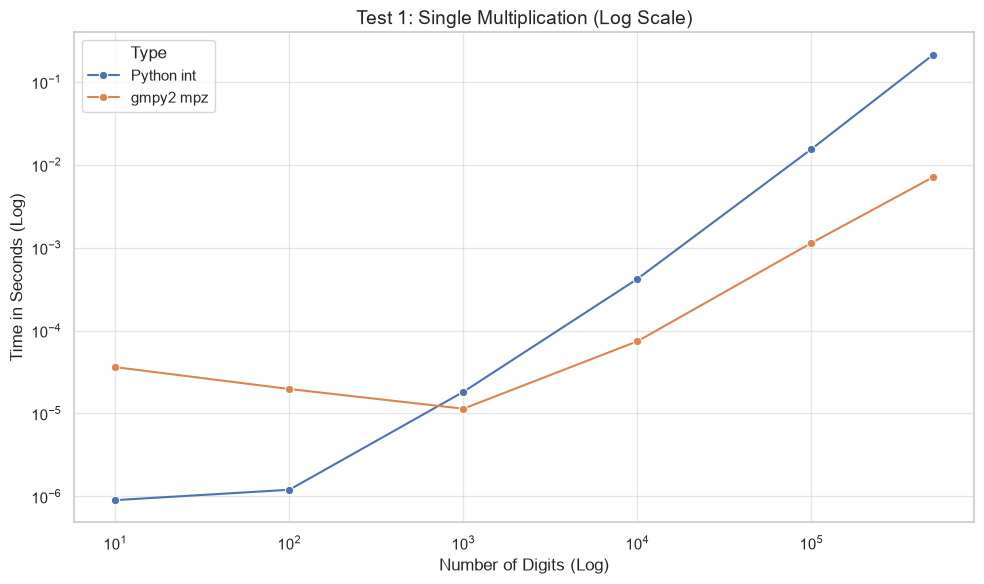

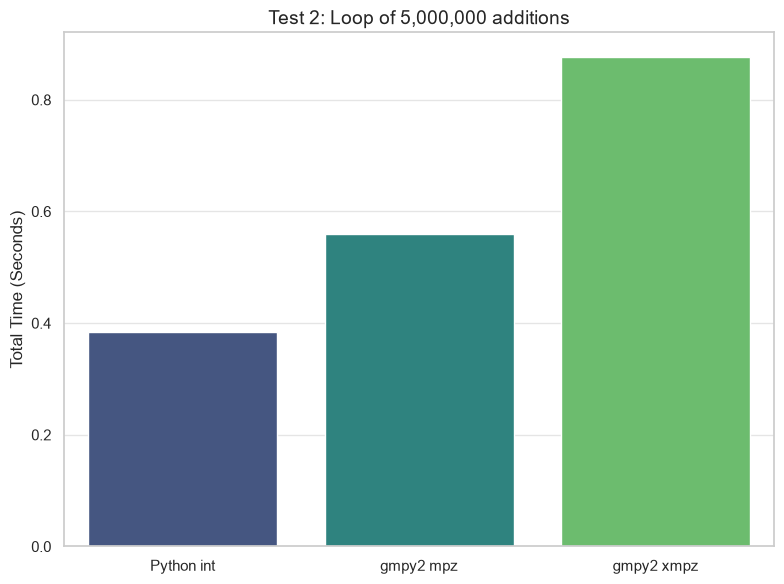

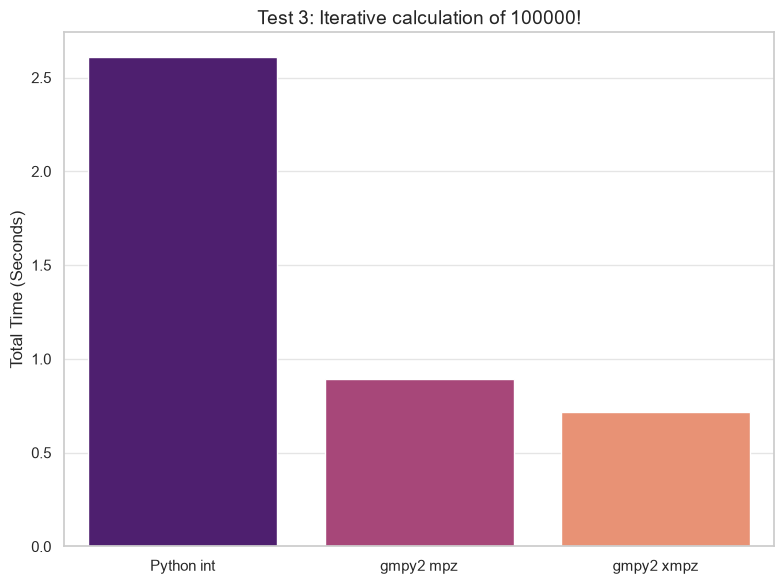

In [5]:
# Convert the test results into Pandas DataFrames
df1 = pd.DataFrame(results_test1)
df2 = pd.DataFrame(results_test2)
df3 = pd.DataFrame(results_test3)

# PLOT 1: The Crossover Point
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df1, 
    x='Digits', 
    y='Time_Seconds', 
    hue='Type', 
    marker='o'
)
plt.title('Test 1: Single Multiplication (Log Scale)', fontsize=14)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Digits (Log)', fontsize=12)
plt.ylabel('Time in Seconds (Log)', fontsize=12)
plt.tight_layout()
plt.show()

# PLOT 2: Memory Stress Test
plt.figure(figsize=(8, 6))
sns.barplot(
    data=df2, 
    x='Type', 
    y='Time_Seconds', 
    hue='Type',
    palette='viridis'
)
plt.title(f'Test 2: Loop of {iterations:,} additions', fontsize=14)
plt.ylabel('Total Time (Seconds)', fontsize=12)
plt.xlabel('')
plt.tight_layout()
plt.show()

# PLOT 3: Iterative Factorial
plt.figure(figsize=(8, 6))
sns.barplot(
    data=df3, 
    x='Type', 
    y='Time_Seconds', 
    hue='Type',
    palette='magma'
)
plt.title(f'Test 3: Iterative calculation of {target_factorial}!', fontsize=14)
plt.ylabel('Total Time (Seconds)', fontsize=12)
plt.xlabel('')
plt.tight_layout()
plt.show()
